In [71]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier


from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

In [72]:
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data
y = faces.target
images = faces.images

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 4096) (80, 4096) (320,) (80,)


In [74]:
unique_people = np.unique(y)
len(unique_people)

40

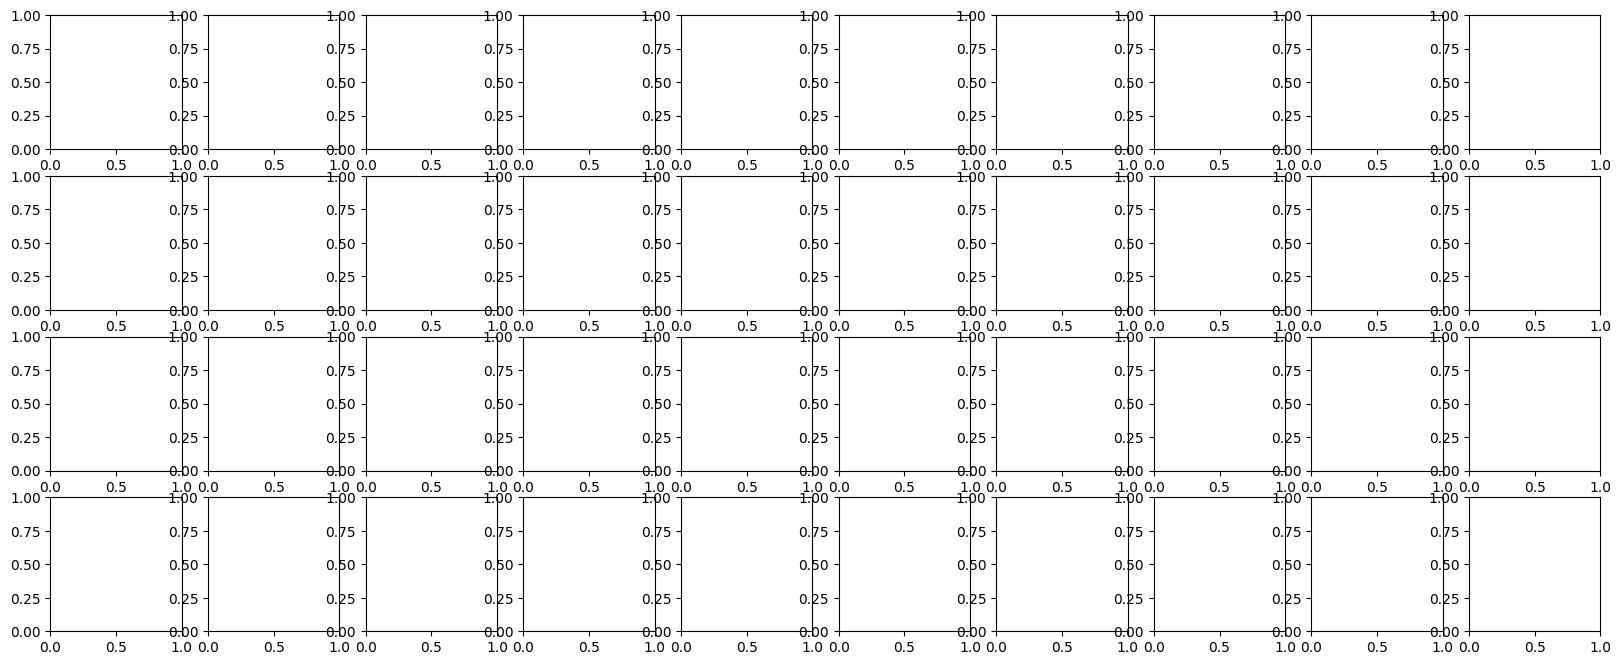

In [75]:
fig, axes = plt.subplots(4, 10, figsize=(20,8))
axes = axes.ravel()

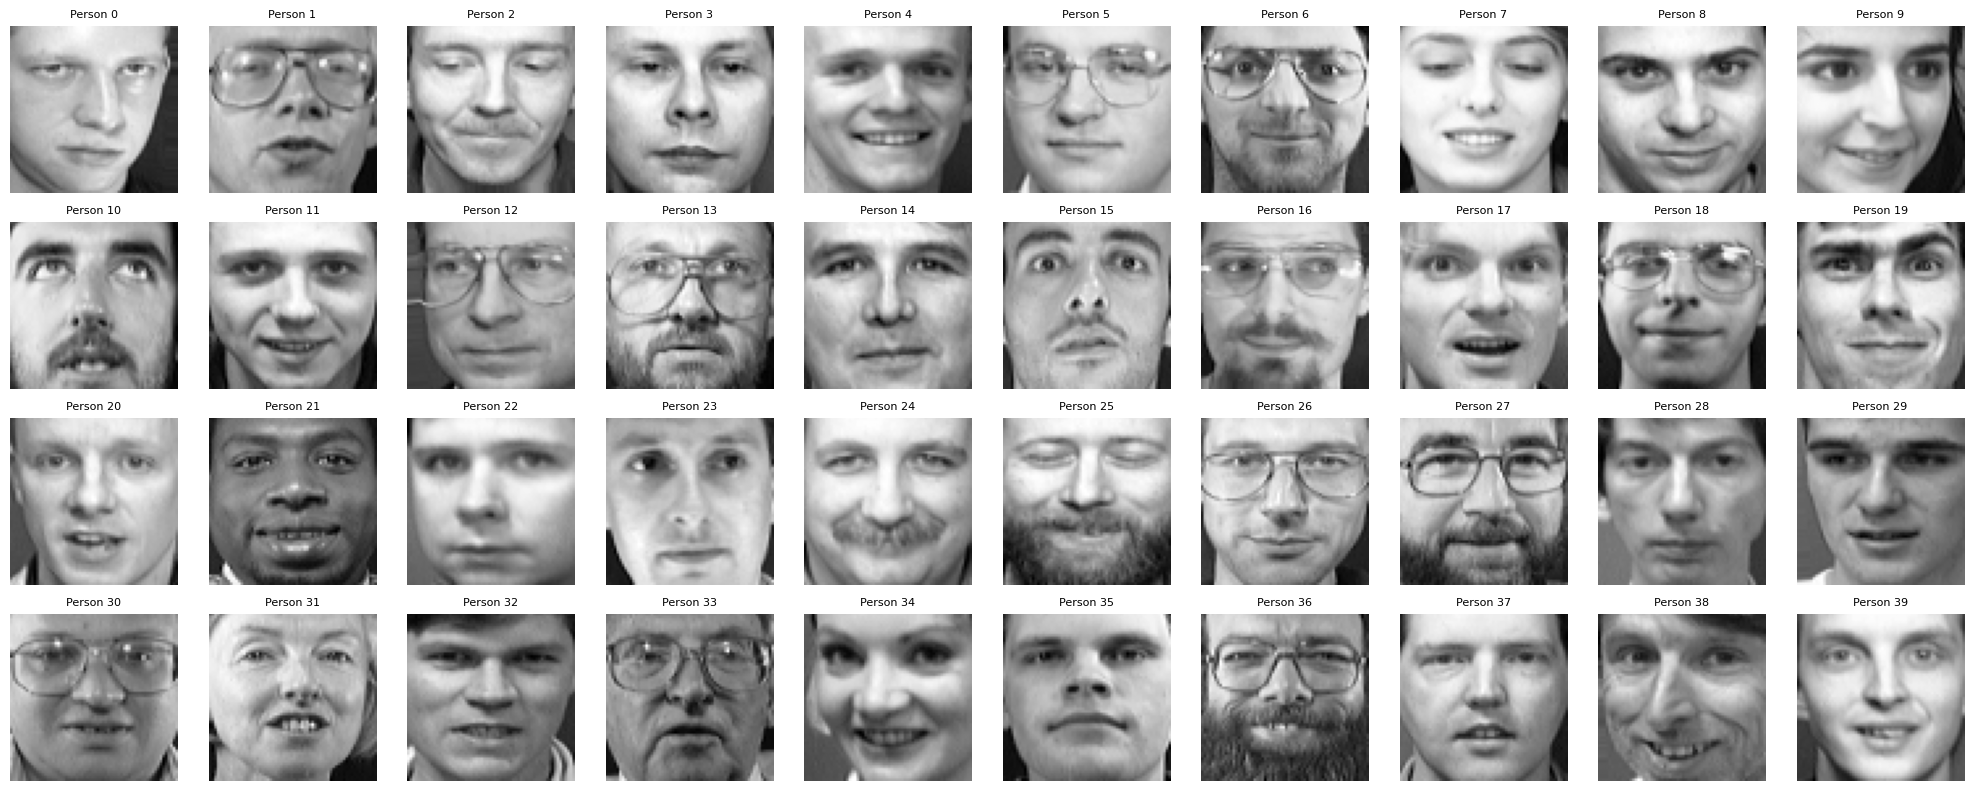

In [76]:
fig, axes = plt.subplots(4, 10, figsize=(20,8))

axes_flat = axes.flatten()

for i, person_id in enumerate(unique_people):
    idx = np.where(y == person_id)[0][0]
    axes_flat[i].imshow(images[idx], cmap='gray')
    axes_flat[i].set_title(f"Person {person_id}", fontsize=8)
    axes_flat[i].axis('off')
    
plt.tight_layout()
plt.show()

In [77]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train,y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_svm

0.9625

In [78]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       0.67      1.00      0.80         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       0.67      1.00      0.80         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       0.67      1.00      0.80         2
          17       1.00    

In [79]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)
acc_rfc = accuracy_score(y_test, y_pred_rfc)
acc_rfc

0.95

In [80]:
ab = AdaBoostClassifier(n_estimators=100, random_state=42)
ab.fit(X_train, y_train)
y_pred_ab = ab.predict(X_test)
acc_ab = accuracy_score(y_test, y_pred_ab)
acc_ab

0.1625

- SVM model 96.25% ,this works with RBF kernel
- Random Forest model 95%
- AdaBoost model 16.25% underfit!

to make the adaboost better i want to use pca<br>
- i want to decrease the 4096 pixels to 150 pixels

In [81]:
pca = PCA(n_components=150, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

- i increases the depth of the adaboost tree from 1 to 3

In [82]:
base_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

In [83]:
ab_pca = AdaBoostClassifier(estimator=base_tree, n_estimators=100, random_state=42)
ab_pca.fit(X_train_pca, y_train)

y_pred_ab_pca = ab_pca.predict(X_test_pca)
acc_ab_pca = accuracy_score(y_test, y_pred_ab_pca)
acc_ab_pca

0.575